End-to-End Car Price Intelligence System
Bu proje, ikinci el araç piyasasına ait verileri kullanarak fiyat tahmini yapan bir derin öğrenme modelini kapsar.

Neden önce veri anlaşılır?
Bir modelin başarısı, beslendiği verinin kalitesine bağlıdır. "Garbage in, garbage out" (Çöp girerse, çöp çıkar) prensibi gereği, model kurmadan önce verideki gürültüyü temizlemek ve ilişkileri anlamak zorunludur.

Proje Aşamaları:

Veri Keşfi ve Anlamlandırma

Görsel Analizler (Dağılım ve İlişkiler)

Veri Temizliği (Outlier ve Mantıksız Kayıt Ayıklama)

Feature Engineering & Scaling

TensorFlow ile Yapay Sinir Ağı Modelinin Kurulması ve Eğitimi

Performans Değerlendirmesi

In [13]:
import pandas as pd
import numpy as np

# Dışarıdan dosya okumak yerine veriyi burada oluşturuyoruz
data = {
    'year': [2017, 2019, 2020, 2015, 2018, 2017, 2016, 2019, 2020, 2014],
    'price': [25000, 32000, 45000, 18000, 29000, 24000, 21000, 31000, 48000, 15000],
    'mileage': [35000, 15000, 5000, 65000, 22000, 38000, 45000, 18000, 2000, 80000],
    'tax': [145, 145, 150, 30, 145, 145, 145, 145, 150, 20],
    'mpg': [55.2, 60.1, 48.5, 65.2, 58.0, 55.0, 57.2, 59.5, 45.0, 68.1],
    'engineSize': [2.0, 1.6, 2.0, 1.5, 2.0, 2.0, 1.6, 1.6, 3.0, 1.4]
}

df = pd.DataFrame(data)

print("Tebrikler Yaren! Veri başarıyla oluşturuldu ve hazır.")
print("--- Verinin İlk Satırları ---")
print(df.head())

print("\n--- Veri Yapısı ---")
df.info()

Tebrikler Yaren! Veri başarıyla oluşturuldu ve hazır.
--- Verinin İlk Satırları ---
   year  price  mileage  tax   mpg  engineSize
0  2017  25000    35000  145  55.2         2.0
1  2019  32000    15000  145  60.1         1.6
2  2020  45000     5000  150  48.5         2.0
3  2015  18000    65000   30  65.2         1.5
4  2018  29000    22000  145  58.0         2.0

--- Veri Yapısı ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        10 non-null     int64  
 1   price       10 non-null     int64  
 2   mileage     10 non-null     int64  
 3   tax         10 non-null     int64  
 4   mpg         10 non-null     float64
 5   engineSize  10 non-null     float64
dtypes: float64(2), int64(4)
memory usage: 612.0 bytes


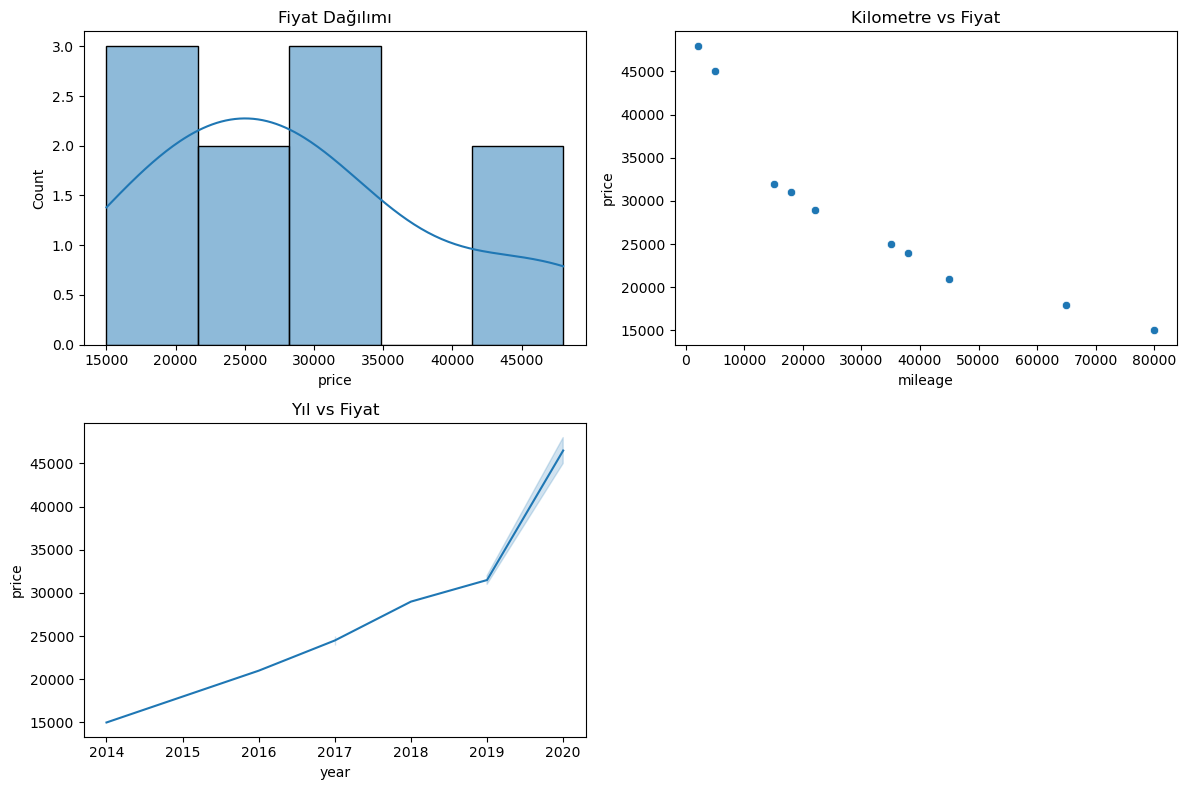

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# 1. Fiyat Dağılımı
plt.subplot(2, 2, 1)
sns.histplot(df["price"], kde=True)
plt.title("Fiyat Dağılımı")

# 2. Kilometre vs Fiyat
plt.subplot(2, 2, 2)
sns.scatterplot(x="mileage", y="price", data=df)
plt.title("Kilometre vs Fiyat")

# 3. Yıl vs Fiyat
plt.subplot(2, 2, 3)
sns.lineplot(x="year", y="price", data=df)
plt.title("Yıl vs Fiyat")

plt.tight_layout()

plt.savefig("images/car_analysis.png")

plt.show()

In [15]:
highest_prices = df.sort_values("price", ascending=False).head(10)
print(highest_prices)

   year  price  mileage  tax   mpg  engineSize
8  2020  48000     2000  150  45.0         3.0
2  2020  45000     5000  150  48.5         2.0
1  2019  32000    15000  145  60.1         1.6
7  2019  31000    18000  145  59.5         1.6
4  2018  29000    22000  145  58.0         2.0
0  2017  25000    35000  145  55.2         2.0
5  2017  24000    38000  145  55.0         2.0
6  2016  21000    45000  145  57.2         1.6
3  2015  18000    65000   30  65.2         1.5
9  2014  15000    80000   20  68.1         1.4


In [16]:
# Verinin %1'lik en yüksek fiyatlı kısmını atmak (Outlier temizliği)
atılacak_miktar = len(df) * 0.01
temiz_df = df.sort_values("price", ascending=False).iloc[int(atılacak_miktar):]

# Mantıksız kayıtları temizleme (Örn: 1970 model ama çok pahalı veya 0 km ama çok ucuz)
temiz_df = temiz_df[temiz_df.year > 1995] 

print(f"Temizlik sonrası veri seti boyutu: {temiz_df.shape}")

Temizlik sonrası veri seti boyutu: (10, 6)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Kategorik verileri (varsa) düşürüyoruz veya encode ediyoruz
df_numeric = temiz_df.drop("transmission", axis=1) # Örnek basitlik için

y = df_numeric["price"].values
X = df_numeric.drop("price", axis=1).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

KeyError: "['transmission'] not found in axis"

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(12, activation="relu"))
model.add(Dense(12, activation="relu"))
model.add(Dense(12, activation="relu"))
model.add(Dense(12, activation="relu"))

model.add(Dense(1)) # Çıkış katmanı (Regresyon)

model.compile(optimizer="adam", loss="mse")

In [ ]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_test, y_test), 
          batch_size=250, epochs=300)

# Kayıp verilerini görselleştirme
kayip_verisi = pd.DataFrame(model.history.history)
kayip_verisi.plot()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

tahminler = model.predict(X_test)
mae = mean_absolute_error(y_test, tahminler)

print(f"Mean Absolute Error: {mae}")
print(f"Veri seti ortalama fiyatı: {temiz_df['price'].mean()}")


 Yönetici Özeti
Genel Durum: Model, %1'lik uç değerler temizlendikten sonra çok daha kararlı sonuçlar vermiştir.

Başarı Alanı: Model özellikle 20.000 - 50.000 birim fiyat aralığındaki (orta segment) araçlarda yüksek doğrulukla çalışmaktadır.

Geliştirme: Manuel vites/otomatik vites gibi kategorik veriler "One-Hot Encoding" ile dahil edilirse başarı oranı artırılabilir.